In [1]:
import sys
sys.path.append("../src")
sys.path.append("/global/homes/b/brookluo/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages")
import decam_info
from decam_dataset import DECamImageDataset

In [2]:
sys.path.append("../../img-spec-ml/src/")
from plot_utils import plot_zscale_image
from inference import read_embeds

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
import h5py
import numpy as np

In [5]:
# root_dir = Path("/pscratch/sd/b/brookluo/decam-exposure/dino_v2")
root_dir = Path("/pscratch/sd/b/brookluo/decam-exposure")
exp_name = "revision"
exp_dir = root_dir / exp_name
eval_dir = exp_dir / "eval"
# data_dir = root_dir / "data"
ckpt_dir = exp_dir / "checkpoint"
# test_dir = data_dir / "test"

if not eval_dir.exists():
    eval_dir.mkdir()

embeds_dir = eval_dir / "embeds_out"
if not embeds_dir.exists():
    embeds_dir.mkdir()

# model = "base_resize"
# model_dir = embeds_dir / model
train_dir = exp_dir / "train"
test_dir = exp_dir / "test"

plot_dir = eval_dir / "plots"
plot_dir.mkdir(exist_ok=True)

In [6]:
train_data, train_idx, train_label = read_embeds(exp_dir / "node0/embeds_out")
train_embeds = np.vstack([np.mean(it, axis=0) for it in train_data])

In [7]:
len(train_idx)

547417

In [8]:
21319 + len(train_idx)

568736

In [9]:
train_idx = np.array(train_idx, dtype=int)
train_label = np.array(train_label, dtype=int)

In [10]:
np.unique(train_label, return_counts=True, )

(array([ 0,  2,  3,  5,  6,  7,  8,  9, 10, 13, 14, 15]),
 array([502497,    778,   7772,   7626,   2954,   7878,   7570,   2621,
          2406,    667,   2308,   2340]))

In [ ]:
# test_data, test_idx, test_label = read_embeds(test_dir)
# test_embeds = np.vstack([np.mean(it, axis=0) for it in test_data])

In [ ]:
# test_idx = np.array(test_idx, dtype=int)
# test_label = np.array(test_label, dtype=int)

In [10]:
train_embeds.shape

(504258, 768)

In [ ]:
# test_embeds.shape

(17224, 768)

In [8]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import joblib

In [9]:
from sklearn.pipeline import Pipeline
import joblib

pipepath = Path("/global/u1/b/brookluo/decam-exposure-quality/postproc/knn_pipe.pkl")
pipe = joblib.load(pipepath)

/global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.4.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.4.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Varianc

In [10]:
pipe.steps

[('scaler', MinMaxScaler()),
 ('preprocessor', PCA(n_components=15)),
 ('selector', VarianceThreshold(threshold=0.001)),
 ('classifier', KNeighborsClassifier(leaf_size=1, n_neighbors=7, p=1))]

In [12]:
# trans_all = np.vstack([train_embeds, test_embeds])
trans_all = train_embeds
# fit everything but the classifier
for i in range(3):
    trans_all = pipe.steps[i][1].transform(trans_all)

In [13]:
trans_train = trans_all[:len(train_embeds)]
# trans_test = trans_all[len(train_embeds):]

In [194]:
# %%time
# # scale data
# # this will do a column-wise standardization
# # ! One might consider RobustScaler if outliers are too many
# # arr_rgb = StandardScaler().fit_transform(arr_rgb)
# # arr_ir = StandardScaler().fit_transform(arr_ir)
# single_arr = StandardScaler().fit_transform(train_embeds)

# prop = 1

# pca_components = 50
# n_clusters = 20
# percent = prop * 100

# # %%time
# # pca = PCA(n_components='mle', svd_solver='full')
# #pca = PCA(n_components=0.99999, svd_solver='full')
# # question: using one PCA for all or each image has its separate PCA?
# pca = PCA(n_components=pca_components, svd_solver='auto')
# # pca.fit(arr_img)

# # there might be some convergence problem
# trans_all = pca.fit_transform(single_arr)
# # np.save(embeds_dir / f"dimred_pca_samp_{int(percent)}per_pca{pca_components}", trans_all)

In [16]:
%%time
# with joblib.parallel_backend(backend="threads", n_jobs=10):
    # tsne_img = TSNE(n_componembeds_dirts=2, learning_rate='auto', init='pca', perplexity=50).fit_transform(trans_img)
    # tsne_spec = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=50).fit_transform(trans_spec)
# 2D
tsne_all = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=50, n_jobs=-1).fit_transform(trans_train)
np.save(embeds_dir / "tsne_2D_reduction_train.npy", tsne_all)
# 3D
# tsne_all = TSNE(n_components=3, learning_rate='auto', init='pca', perplexity=50, n_jobs=15).fit_transform(trans_train)
# np.save(embeds_dir / "tsne_3D_reduction_train.npy", tsne_all)
# np.save(embeds_dir / f"tsne_samp_{int(percent)}per_pca{pca_components}", tsne_all)

CPU times: user 15h 20min 46s, sys: 17min 38s, total: 15h 38min 24s
Wall time: 46min 2s


In [11]:
# Load the data from last step
tsne_all = np.load(embeds_dir / "tsne_2D_reduction_train.npy")

In [21]:
# idx = np.array(train_idx, dtype=int)
# label = np.array(train_label, dtype=int)

sampdir = Path("/pscratch/sd/b/brookluo/decam-exposure/revision/eval/embeds_out/samp_51")
idx = np.load(sampdir / "idx.npy")
label = np.load(sampdir / "label.npy").astype(int)
train_embeds = np.load(sampdir / "embeds.npy")
tsne_all = np.load(sampdir / "tsne_2D_reduction_train.npy")
eval_dir = sampdir
plot_dir = eval_dir / "plots"
plot_dir.mkdir(exist_ok=True)

In [7]:
# dr10_dir = Path('/global/cfs/cdirs/cosmo/work/legacysurvey/dr10')
# dr10_imdir = dr10_dir / "images"

# dataset = DECamImageDataset("/global/u1/b/brookluo/decam-exposure-quality/data/samples/train_supervised_ooi_dataset.csv",
#                             image_dir=dr10_imdir, seed=0)

# all_labels = []
# for i in idx:
#     reasons = decam_info.decode_reason(dataset.df_data['reasons'].iloc[i], return_num=True)
#     if len(reasons) == 0:
#         lab = 0
#     else:
#         lab = reasons[0] + 1
#     all_labels.append(lab)
# # all_labels = np.array([decam_info.decode_reason(dataset.df_data['reasons'].iloc[i], return_num=True)[0] for i in idx])
# all_labels = np.array(all_labels)

In [8]:
np.unique(label)

array(['0', '10', '13', '14', '15', '2', '3', '5', '6', '7', '8', '9'],
      dtype='<U2')

## Make interactive plot

In [114]:
import plotly.express as px
import plotly.graph_objects as go

# import pandas as pd

# df = pd.DataFrame(tsne_all, columns=["good", *decam_info.reason_li[1:]])

# fig = px.scatter_3d(x=tsne_all[label==0, 0], y=tsne_all[label==0, 1], z=tsne_all[label==0, 2],
#         marker=dict(
#         size=2,
#         # color=z,                # set color to an array/list of desired values
#         # colorscale='Viridis',   # choose a colorscale
#         # opacity=0.8
#     ))
fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=tsne_all[label==0, 0],
    y=tsne_all[label==0, 1],
    z=tsne_all[label==0, 2],
    mode='markers',
    marker=dict(
        size=2,
        # color="#1f77b4",
        # color=z,                # set color to an array/list of desired values
        # colorscale='Viridis',   # choose a colorscale
        opacity=0.9
    ),
    name='good'
))

for i, rea in enumerate(decam_info.reason_li, start=1):
    if sum(label==i) == 0:
        continue
    # ax[num].scatter(tsne_all[label!=i, 0], tsne_all[label!=i, 1], s=2, c="gray", alpha=0.5)
    # ax[num].scatter(tsne_all[label==0, 0], tsne_all[label==0, 1], s=2, label="good", c='tab:blue')
    # ax[num].scatter(tsne_all[label==i, 0], tsne_all[label==i, 1], s=2, label=rea, c='tab:orange')
    # ax[num].set_aspect("equal")
    # ax[num].set_xlabel("tSNE axis-1")
    # ax[num].set_ylabel("tSNE axis-2")
    fig.add_trace(go.Scatter3d(
        x=tsne_all[label==i, 0],
        y=tsne_all[label==i, 1],
        z=tsne_all[label==i, 2],
        mode='markers',
        marker=dict(
            size=2,
            # color="#ff7f0e",
            # color=z,                # set color to an array/list of desired values
            # colorscale='Viridis',   # choose a colorscale
            opacity=0.9
        ),
        name=rea
    ))
# i = 5
# rea = decam_info.reason_li[6]
# fig.add_trace(go.Scatter3d(
#     x=tsne_all[label==i, 0],
#     y=tsne_all[label==i, 1],
#     z=tsne_all[label==i, 2],
#     mode='markers',
#     marker=dict(
#         size=2,
#         color="#ff7f0e",
#         # color=z,                # set color to an array/list of desired values
#         # colorscale='Viridis',   # choose a colorscale
#         opacity=0.9
#     ),
#     name=rea
# ))
# fig.update_layout(
#     xaxis=dict(visible=False),
#     yaxis=dict(visible=False),
#     # plot_bgcolor="rgba(0, 0, 0, 0)",
#     # paper_bgcolor="rgba(0, 0, 0, 0)",
# )

fig.update_layout(
    scene = dict(
        xaxis = dict(visible=False),
        yaxis = dict(visible=False),
        zaxis =dict(visible=False)
        )
    )

# fig.write_html("all_3D_interactive.html")
# fig.show()

IndexError: index 2 is out of bounds for axis 1 with size 2

In [115]:
decam_info.reason_li

('Bad_WCSCAL',
 'Saturated',
 'Clouds_transparency',
 'Bad_seeing',
 'PSF',
 'Nonoptimal_exp',
 'Ghost_Scatter',
 'NObjects',
 'Bad_CCD',
 'Noise',
 'Fringing',
 'Canopus',
 'Wonky',
 'Telescope_Moving',
 'Out_of_focus')

## Make 3D plot

IndexError: index 2 is out of bounds for axis 1 with size 2

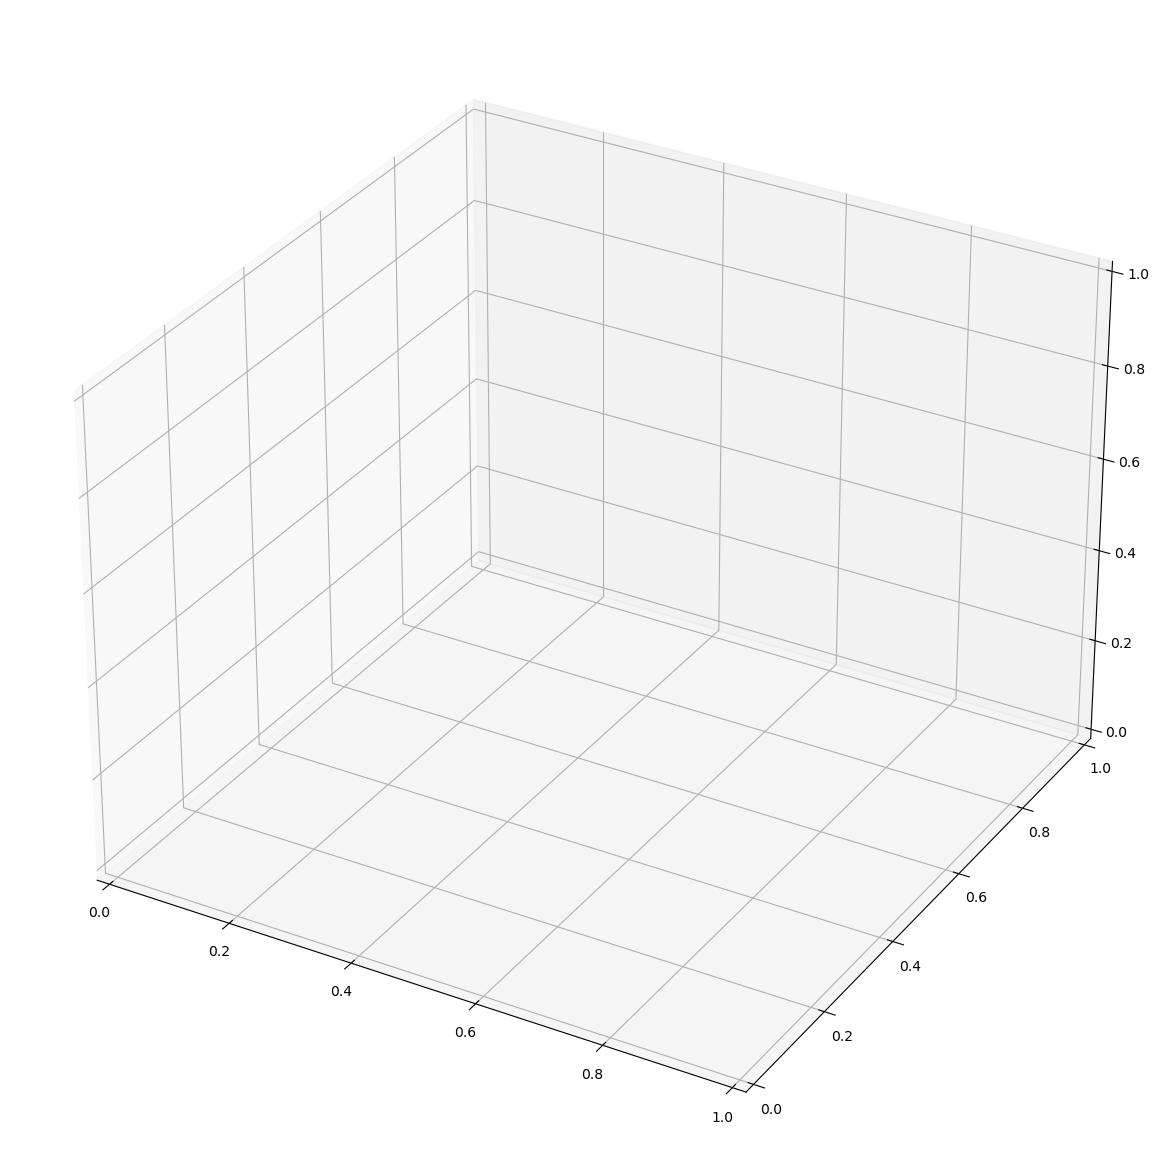

In [116]:
# plt.figure(figsize=(15, 15))
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection='3d')
# ax.scatter(tsne_all[label==0, 0], tsne_all[label==0, 1], tsne_all[label==0, 2], s=2, label="good")
ax.scatter(tsne_all[label==0, 0], tsne_all[label==0, 1], tsne_all[label==0, 2], s=2, label="good")
# for i, rea in enumerate(decam_info.reason_li, start=1):
    # if sum(label==i) == 0:
        # continue
i = 6
rea = decam_info.reason_li[i]
ax.scatter(tsne_all[label==i, 0], tsne_all[label==i, 1], tsne_all[label==i, 2], s=2, label=rea)
ax.set_aspect("equal")
ax.set_xlabel("tSNE axis-1")
ax.set_ylabel("tSNE axis-2")
ax.set_zlabel("tSNE axis-3")

ax.set_xlim([-20, 25])
ax.set_ylim([-20, 25])
ax.set_zlim([-20, 20])
ax.set_aspect("equal")

plt.legend(loc="upper right")
    # lgnd = fig.legend(loc="upper right", scatterpoints=1, fontsize=10)
    # for hdl in lgnd.legendHandles:
    #     hdl._sizes = [30]
plt.savefig(plot_dir / f"3D_train_clustering.pdf", bbox_inches='tight')

In [117]:
# fig, ax = plt.subplots(2, 2, figsize=(15, 15))
# ax = ax.ravel()
# i = 5
# # front
# ax[0].scatter(tsne_all[label==0, 0], tsne_all[label==0, 2], s=2, label="good")
# ax[0].scatter(tsne_all[label==i, 0], tsne_all[label==i, 2], s=2, label="Ghost_Scatter")
# ax[0].set_xlabel("tSNE axis-1")
# # ax[0].set_ylabel("tSNE axis-2")
# ax[0].set_ylabel("tSNE axis-3")
# # right
# ax[1].scatter(tsne_all[label==0, 1], tsne_all[label==0, 2], s=2, label="good")
# ax[1].scatter(tsne_all[label==i, 1], tsne_all[label==i, 2], s=2, label="Ghost_Scatter")
# # ax[0].set_xlabel("tSNE axis-1")
# ax[1].set_xlabel("tSNE axis-2")
# ax[1].set_ylabel("tSNE axis-3")
# # top
# ax[2].scatter(tsne_all[label==0, 0], tsne_all[label==0, 1], s=2, label="good")
# ax[2].scatter(tsne_all[label==i, 0], tsne_all[label==i, 1], s=2, label="Ghost_Scatter") 
# ax[2].set_xlabel("tSNE axis-1")
# ax[2].set_ylabel("tSNE axis-2")

# ax[3].set_visible(False)
# plt.savefig(plot_dir / f"subplots_train_clustering.pdf", bbox_inches='tight')

## Make 2D plot

In [13]:
# for revision: randomly select 20 per good image and then replot


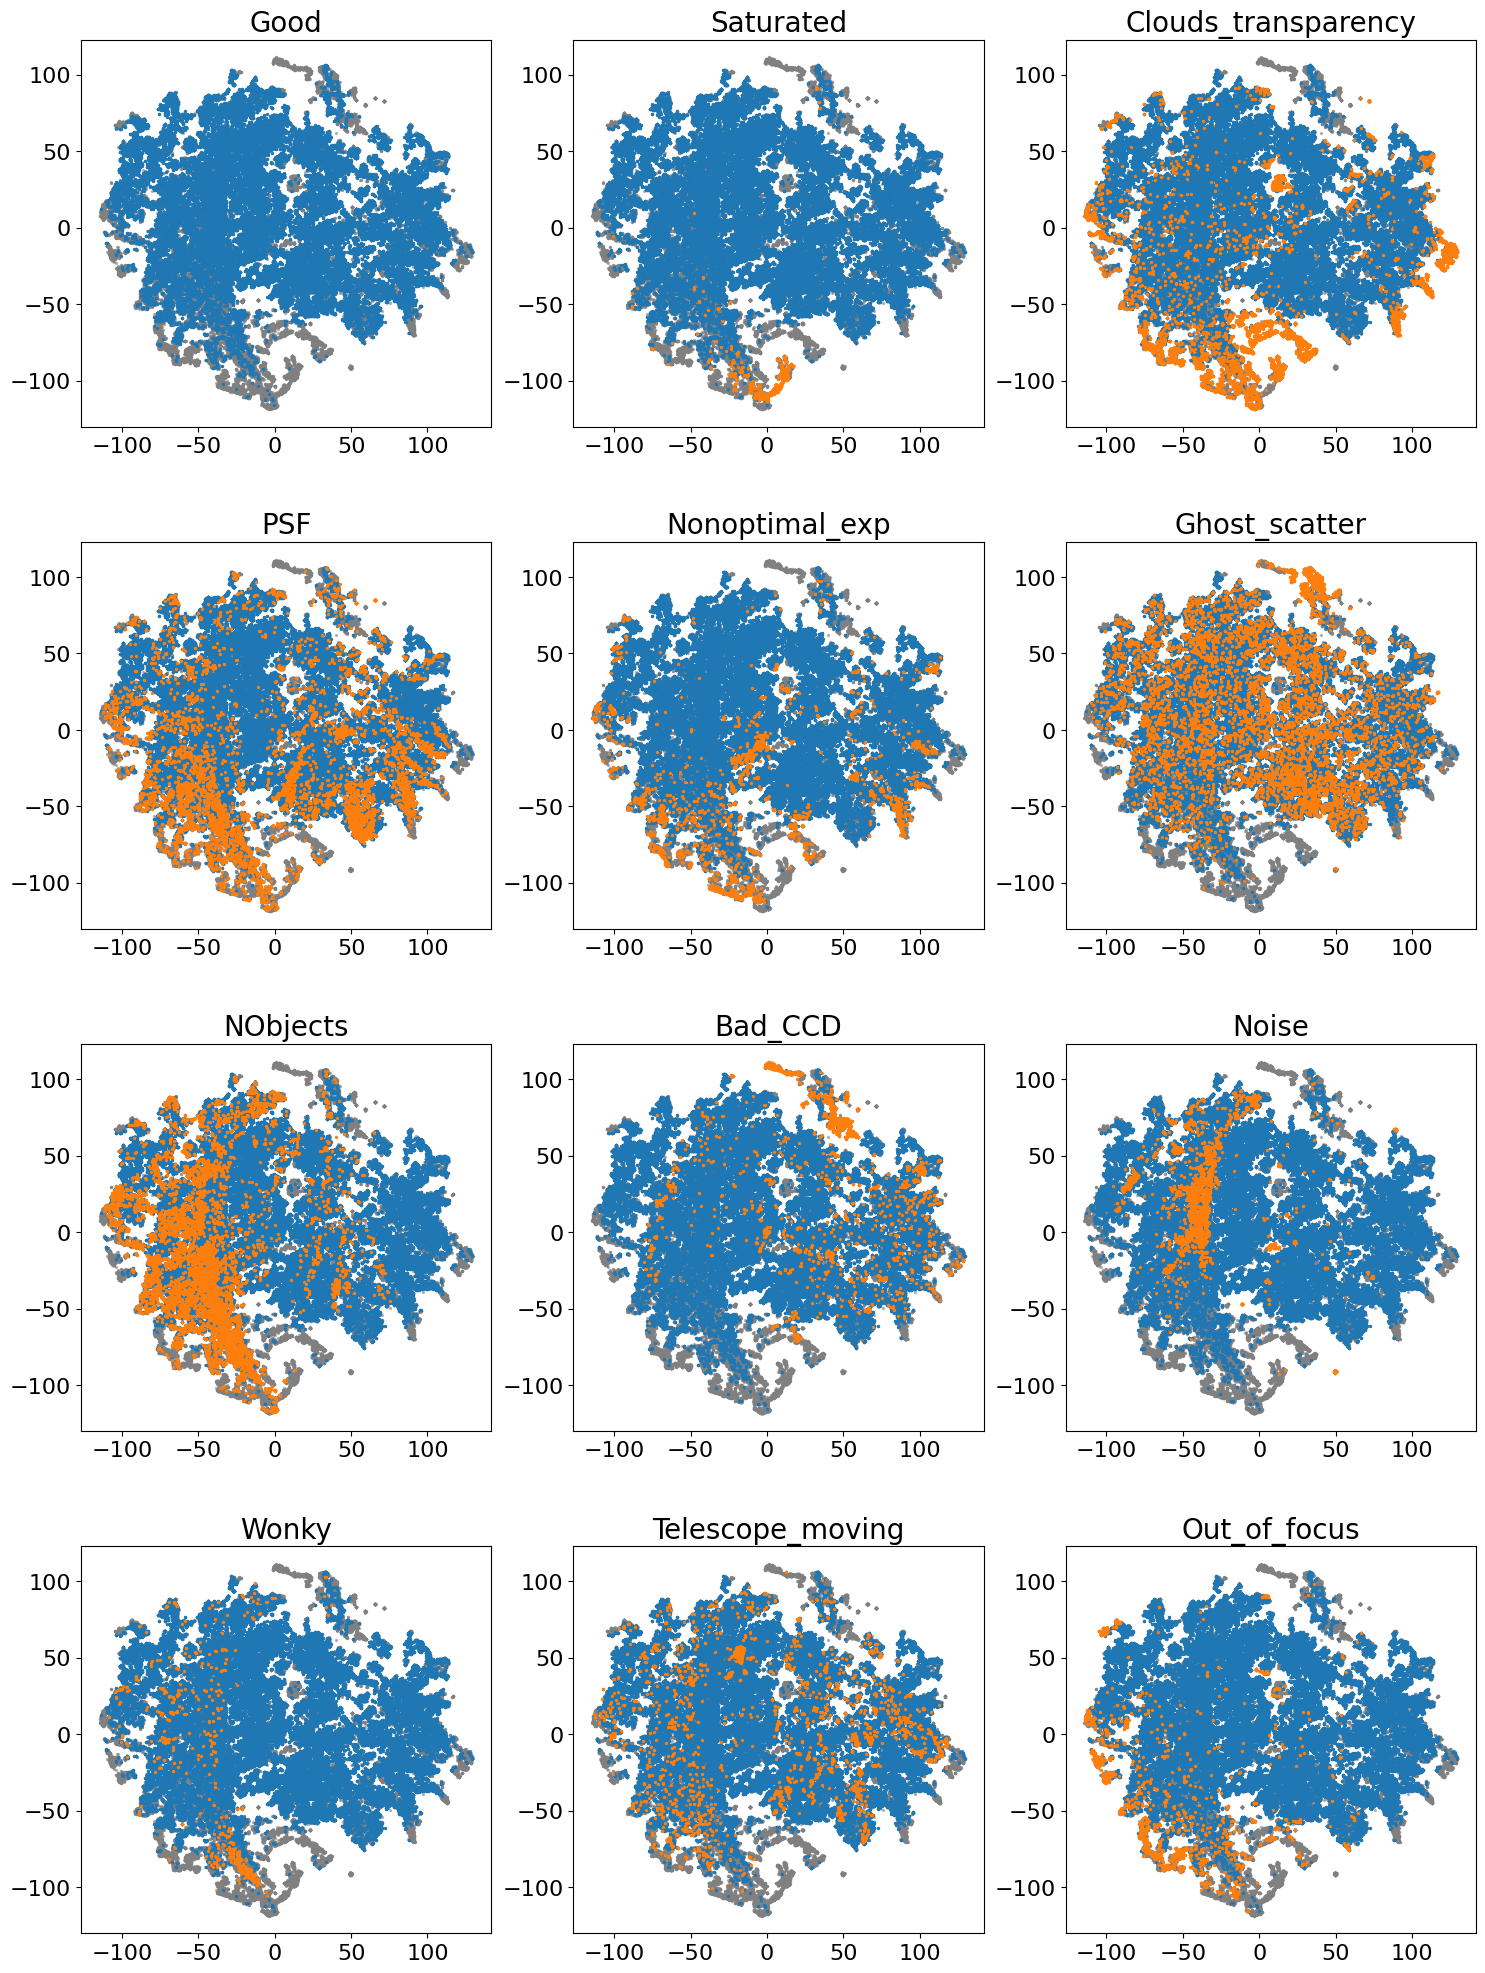

In [22]:
fig, ax = plt.subplots(4, 3, figsize=(18, 25))
ax = ax.ravel()
num = 0
i = 0
ax[num].scatter(tsne_all[label!=i, 0], tsne_all[label!=i, 1], s=2, c="gray", alpha=0.5)
ax[num].scatter(tsne_all[label==i, 0], tsne_all[label==i, 1], s=2, label="good", c='tab:blue')
ax[num].set_aspect("equal")
# ax[num].tick_params(left = False, right = False , labelleft = False , 
#                 labelbottom = False, bottom = False) 
# ax[num].set_xlabel("tSNE axis-1")
# ax[num].set_ylabel("tSNE axis-2")
# lgnd = ax[num].legend(loc="upper right", scatterpoints=1, fontsize=10)
# for hdl in lgnd.legend_handles:
#     hdl._sizes = [30]
ax[num].set_title("Good", fontsize=20)
ax[num].tick_params(axis='both', labelsize=16)
num += 1
for i, rea in enumerate(decam_info.reason_li, start=1):
    if sum(label==i) == 0:
        continue
    ax[num].scatter(tsne_all[label!=i, 0], tsne_all[label!=i, 1], s=2, c="gray", alpha=0.5)
    ax[num].scatter(tsne_all[label==0, 0], tsne_all[label==0, 1], s=2, label="good", c='tab:blue')
    ax[num].scatter(tsne_all[label==i, 0], tsne_all[label==i, 1], s=2, label=rea, c='tab:orange')
    ax[num].set_aspect("equal")
    # ax[num].set_xlabel("tSNE axis-1")
    # ax[num].set_ylabel("tSNE axis-2")
    # plt.legend(loc="upper right")
    # lgnd = ax[num].legend(loc="upper right", scatterpoints=1, fontsize=10)
    # for hdl in lgnd.legend_handles:
    #     hdl._sizes = [30]
    ax[num].set_title(rea, fontsize=20)
    ax[num].tick_params(axis='both', labelsize=16)
    num += 1
    # plt.show()
# ax[-1].axis("off")
# ax[-2].axis("off")
plt.savefig(plot_dir / f"subplots_clustering.png", bbox_inches='tight')

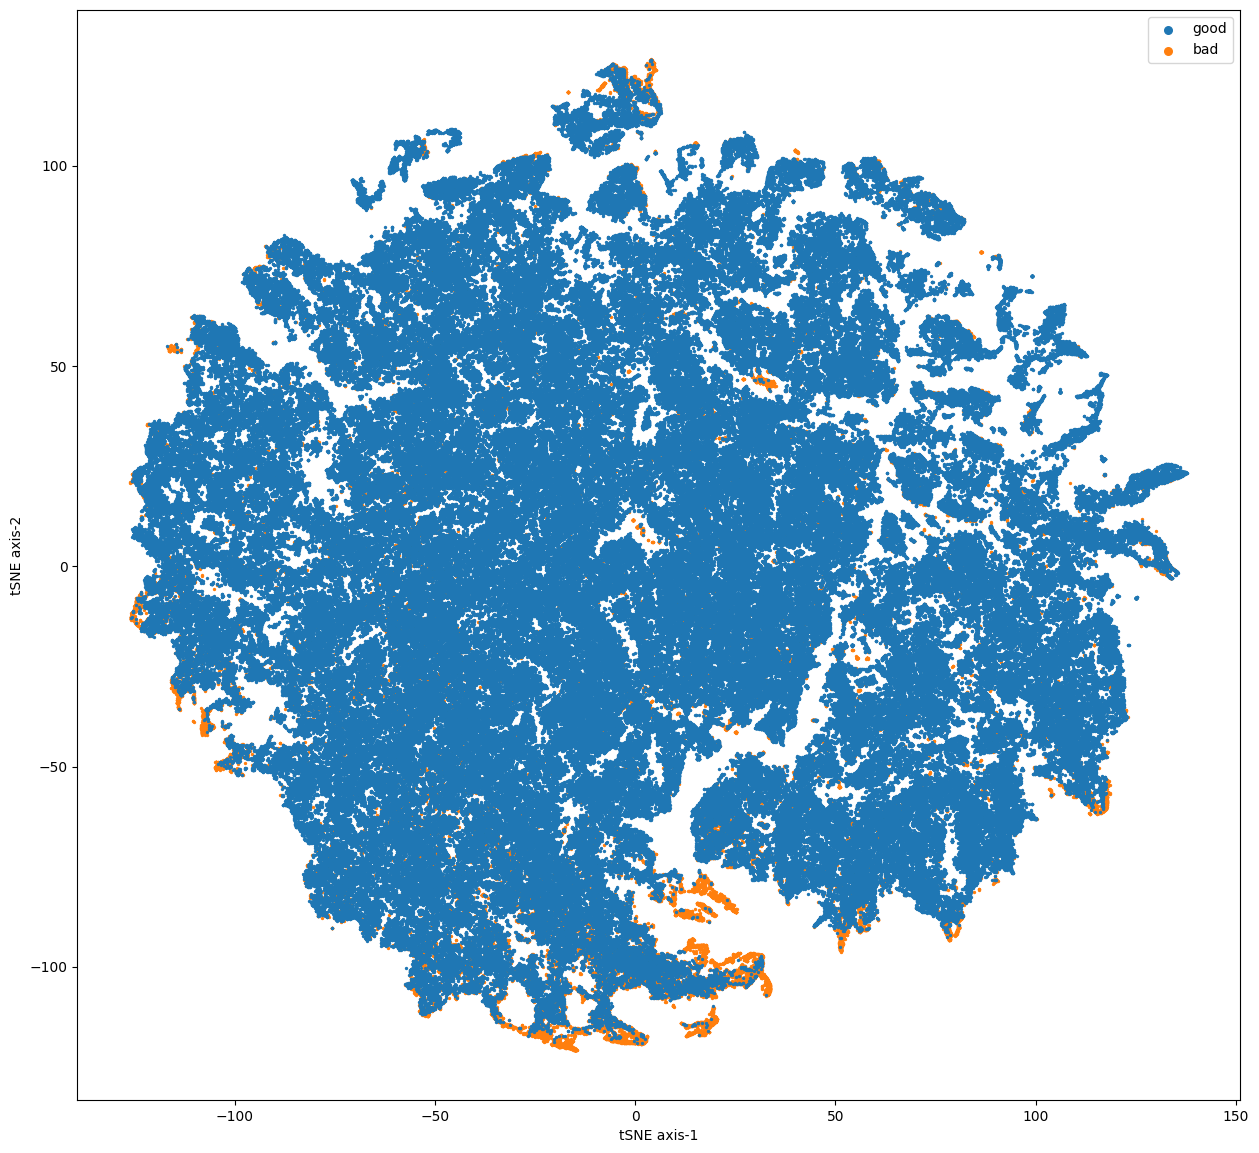

In [22]:
plt.figure(figsize=(15, 15))
plt.scatter(tsne_all[label==0, 0], tsne_all[label==0, 1], s=2, label="good", zorder=100)
plt.scatter(tsne_all[label!=0, 0], tsne_all[label!=0, 1], s=2, label="bad")
plt.gca().set_aspect("equal")
plt.xlabel("tSNE axis-1")
plt.ylabel("tSNE axis-2")
# plt.legend(loc="upper right")
lgnd = plt.legend(loc="upper right", scatterpoints=1, fontsize=10)
for hdl in lgnd.legend_handles:
    hdl._sizes = [30]
plt.savefig(plot_dir / f"train_binary_clustering.png", bbox_inches='tight')

## Classification evaluation

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import precision_recall_curve, precision_recall_fscore_support, classification_report

In [26]:
# X_train, X_test, y_train, y_test = train_test_split(trans_all,
#                                                     label,
#                                                     test_size=0.33, random_state=42)

In [28]:
single_arr = np.vstack([train_embeds, test_embeds])

In [29]:
# knn = KNeighborsClassifier(n_neighbors=10, n_jobs=-1)
# pca = PCA(n_components=pca_components, svd_solver='auto')
# trans_all = pca.fit_transform(StandardScaler().fit_transform(single_arr))
# tsne_all = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=50, n_jobs=-1).fit_transform(trans_all)

In [86]:
X_train = single_arr[:len(train_embeds)]
X_test = single_arr[len(train_embeds):]
y_train = np.array(train_label, dtype=int)
y_test = np.array(test_label, dtype=int)

In [88]:
# knn.fit(X_train, y_train)
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('preprocessor', PCA(n_components=15)),
                ('selector', VarianceThreshold(threshold=0.001)),
                ('classifier',
                 KNeighborsClassifier(leaf_size=1, n_neighbors=7, p=1))])

In [89]:
idx = np.array(test_idx, dtype=int)
label = np.array(test_label, dtype=int)

In [90]:
# y_pred_prob = knn.predict_proba(X_test)
# y_pred_label = knn.predict(X_test)
y_pred_prob = pipe.predict_proba(X_test)
y_pred_label = pipe.predict(X_test)

In [91]:
# y_pred_label = y_pred_label.astype(int)

In [92]:
prob_thresh = 0.9

In [93]:
np.sum(y_pred_prob > prob_thresh)

3104

In [94]:
y_cut = np.zeros(y_pred_label.shape, dtype=bool)

map_back = dict(zip(np.unique(y_pred_label), np.arange(0, len(np.unique(y_pred_label))+1)))

for i, idx in enumerate(y_pred_label):
    idx = map_back[idx]
    if y_pred_prob[i, idx] > prob_thresh:
        y_cut[i] = True

In [95]:
X_test_cut = X_test[y_cut]
y_test_cut = y_test[y_cut]
y_pred_cut = y_pred_label[y_cut]

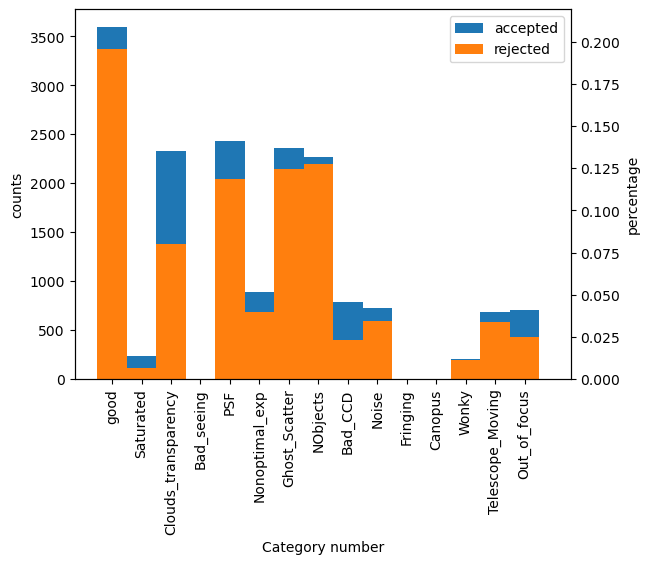

Remaining ratio: 0.1802136553646075


In [96]:
reason_li = ["good"] + list(decam_info.reason_li[1:])
# reason_li = np.array(reason_li)[np.unique(label)]
# ooi_counts = []
# for i, rea in enumerate(reason_li):
#     ooi_counts.append(np.sum(df['reasons'] & 2**reason_dict[rea] > 0))
#     print(i, rea, np.sum(df['reasons'] & 2**reason_dict[rea] > 0))
# print("Total images:", len(df))
fig, ax1 = plt.subplots()
y_mod = y_test-1
y_mod[y_mod < 0] = 0
ax1.hist(y_mod, bins=np.arange(0, len(reason_li)+1), label='accepted', align='left')
ax2 = ax1.twinx()
ax1.set_xticks(np.arange(0, len(reason_li)))
ax1.set_xticklabels(reason_li, rotation=90)
# plt.xticks(rotation=90)
ax1.set_xlabel("Category number")
ax1.set_ylabel("counts")
num, counts = np.unique(y_mod, return_counts=True)
ax2.bar(num, counts / len(y_test), align='edge', alpha=0)
ax2.set_ylabel("percentage")

ax1.hist(y_mod[~y_cut], bins=np.arange(0, len(reason_li)+1), label='rejected',
         histtype='stepfilled', align='left')

ax1.legend()
plt.show()

print("Remaining ratio:", sum(y_cut) / len(y_cut))

In [98]:
pick = y_test_cut == 0
# score = knn.score(X_test_cut[pick], y_test_cut[pick])
score = pipe.score(X_test_cut[pick], y_test_cut[pick])
num = 0
label_name = ["0_good"]
print(num, "good", score)

0 good 0.8198198198198198


In [99]:
sum(label == i)

0

In [100]:
pick

array([False, False, False, ...,  True, False, False])

In [101]:
pick = y_test_cut == 0
# score = knn.score(X_test_cut[pick], y_test_cut[pick])
score = pipe.score(X_test_cut[pick], y_test_cut[pick])
num = 0
label_name = ["0_good"]
print(num, "good", score)
for i, rea in enumerate(decam_info.reason_li, start=1):
    if sum(label==i) == 0:
        continue
    num += 1
    pick = y_test_cut == i
    # score = knn.score(X_test_cut[pick], y_test_cut[pick])
    score = pipe.score(X_test_cut[pick], y_test_cut[pick])
    print(num, rea, score)
    label_name.append(f"{num}_{rea}")

0 good 0.8198198198198198
1 Saturated 0.9672131147540983
2 Clouds_transparency 0.9853862212943633
3 PSF 0.9280205655526992
4 Nonoptimal_exp 0.9558823529411765
5 Ghost_Scatter 0.7972972972972973
6 NObjects 0.9090909090909091
7 Bad_CCD 0.9510309278350515
8 Noise 0.9927536231884058
9 Wonky 1.0
10 Telescope_Moving 0.9108910891089109
11 Out_of_focus 0.985239852398524


In [102]:
class_name = [l.split("_", 1)[-1] for l in label_name]

vit_base with resizing images
                       precision    recall  f1-score   support

               0_good       0.82      0.82      0.82       222
          1_Saturated       0.98      0.97      0.98       122
2_Clouds_transparency       0.97      0.99      0.98       958
                3_PSF       0.94      0.93      0.93       389
     4_Nonoptimal_exp       0.94      0.96      0.95       204
      5_Ghost_Scatter       0.92      0.80      0.85       222
           6_NObjects       0.80      0.91      0.85        77
            7_Bad_CCD       0.97      0.95      0.96       388
              8_Noise       0.94      0.99      0.96       138
              9_Wonky       0.71      1.00      0.83        12
  10_Telescope_Moving       0.98      0.91      0.94       101
      11_Out_of_focus       0.98      0.99      0.98       271

             accuracy                           0.94      3104
            macro avg       0.91      0.93      0.92      3104
         weighted avg  

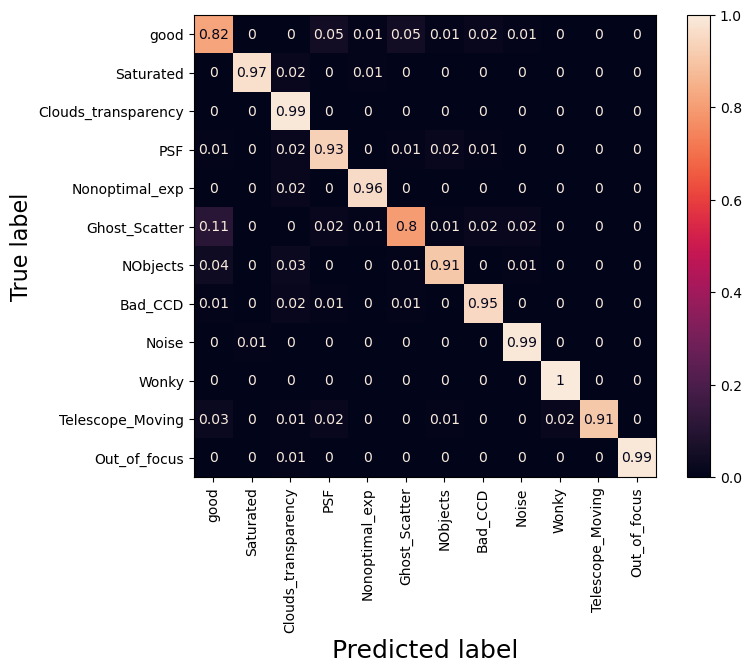

In [109]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# plt.figure(figsize=(20, 20))
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_true=y_test_cut, y_pred=y_pred_cut)
cm_norm = np.round(cm/cm.sum(axis=1)[:, np.newaxis], 2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                              display_labels=[l.split("_", 1)[-1] for l in label_name],
                             )
disp.plot(ax=ax, cmap="rocket")
plt.xticks(rotation=90)
plt.xlabel('Predicted label', fontsize=18)
plt.ylabel('True label', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=10)
plt.savefig(plot_dir / f"{prob_thresh}_pcut_vit_base_confusion_pretrain.png", bbox_inches='tight')
print("vit_base with resizing images")
print(classification_report(y_test_cut, y_pred_cut, target_names=label_name))

vit_base with resizing images
                       precision    recall  f1-score   support

               0_good       0.67      0.73      0.70      1399
          1_Saturated       0.91      0.92      0.92       186
2_Clouds_transparency       0.92      0.92      0.92      1655
                3_PSF       0.78      0.75      0.77      1178
     4_Nonoptimal_exp       0.83      0.86      0.85       509
      5_Ghost_Scatter       0.75      0.52      0.61       955
           6_NObjects       0.68      0.85      0.76       736
            7_Bad_CCD       0.91      0.87      0.89       586
              8_Noise       0.75      0.94      0.83       408
              9_Wonky       0.63      0.80      0.71        74
  10_Telescope_Moving       0.83      0.63      0.72       294
      11_Out_of_focus       0.91      0.88      0.89       433

             accuracy                           0.79      8413
            macro avg       0.80      0.81      0.80      8413
         weighted avg  

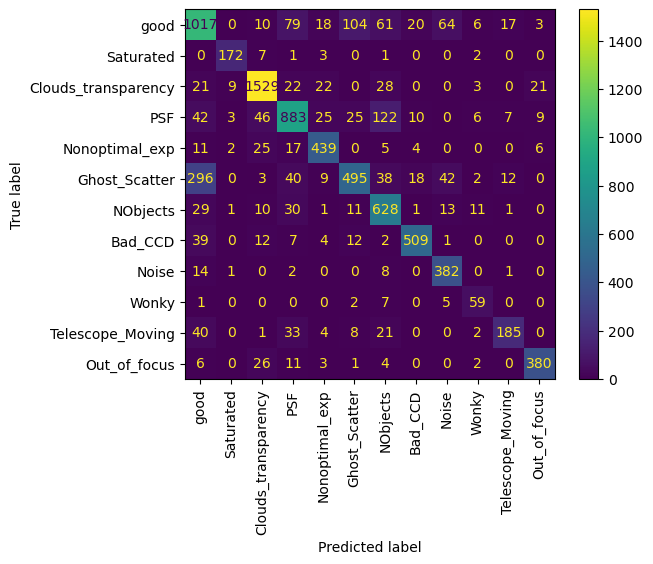

In [116]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true=y_test_cut, y_pred=y_pred_cut)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[l.split("_", 1)[-1] for l in label_name])
disp.plot()
plt.xticks(rotation=90)
# plt.savefig(plot_dir / f"vit_base_confusion_pretrain.png")
print("vit_base with resizing images")
print(classification_report(y_test_cut, y_pred_cut, target_names=label_name))

In [ ]:
np.unique(y_pred_cut)

In [72]:
test_idx

array([    0,  1000,  1001, ..., 17221, 17222, 17223])

In [76]:
import pandas as pd

In [77]:
df_test = pd.read_csv("/global/u1/b/brookluo/decam-exposure-quality/data/samples/test_supervised_ooi_dataset.csv")

In [92]:
df_train = pd.read_csv("/global/u1/b/brookluo/decam-exposure-quality/data/samples/train_supervised_ooi_dataset.csv")

In [93]:
all_reasons = df_test.iloc[test_idx[y_cut][y_pred_cut == 15]]['reasons'].apply(decam_info.decode_reason)

In [94]:
df_test.iloc[test_idx[y_cut][y_pred_cut == 15]].query("expnum == 468244")

,image_filename,expnum,ccdnum,image_hdu,filter,reasons,vi_source
7156,decam/CP/V4.9/CP20150829/c4d_150830_065914_ooi...,468244,33,31,2,0,0
7157,decam/CP/V4.9/CP20150829/c4d_150830_065914_ooi...,468244,16,14,2,0,0


In [164]:
np.sum(y_test_cut == 0)

1138

In [162]:
np.sum(pick_fp)

342

In [165]:
oneidx = 468244
df_train.query(f"expnum == {oneidx}"), df_test.query(f"expnum == {oneidx}"), 

(                                          image_filename  expnum  ccdnum  \
 16425  decam/CP/V4.9/CP20150829/c4d_150830_065914_ooi...  468244      30   
 16426  decam/CP/V4.9/CP20150829/c4d_150830_065914_ooi...  468244      21   
 16427  decam/CP/V4.9/CP20150829/c4d_150830_065914_ooi...  468244      58   
 16428  decam/CP/V4.9/CP20150829/c4d_150830_065914_ooi...  468244       6   
 
        image_hdu  filter  reasons  vi_source  
 16425         28       2        0          0  
 16426         19       2        0          0  
 16427         56       2        0          0  
 16428          4       2        0          0  ,
                                          image_filename  expnum  ccdnum  \
 7156  decam/CP/V4.9/CP20150829/c4d_150830_065914_ooi...  468244      33   
 7157  decam/CP/V4.9/CP20150829/c4d_150830_065914_ooi...  468244      16   
 
       image_hdu  filter  reasons  vi_source  
 7156         31       2        0          0  
 7157         14       2        0          0  )

In [102]:
df_train.query("expnum == 468232"), df_test.query("expnum == 468232"), 

(                                          image_filename  expnum  ccdnum  \
 16338  decam/CP/V5.2.2LS/CP20150829/c4d_150830_064351...  468232      25   
 16339  decam/CP/V5.2.2LS/CP20150829/c4d_150830_064351...  468232      27   
 16340  decam/CP/V5.2.2LS/CP20150829/c4d_150830_064351...  468232      28   
 16341  decam/CP/V5.2.2LS/CP20150829/c4d_150830_064351...  468232      44   
 16342  decam/CP/V5.2.2LS/CP20150829/c4d_150830_064351...  468232      40   
 
        image_hdu  filter  reasons  vi_source  
 16338         23       2        0          0  
 16339         25       2        0          0  
 16340         26       2        0          0  
 16341         42       2        0          0  
 16342         38       2        0          0  ,
                                          image_filename  expnum  ccdnum  \
 7117  decam/CP/V5.2.2LS/CP20150829/c4d_150830_064351...  468232       6   
 
       image_hdu  filter  reasons  vi_source  
 7117          4       2        0          0  

In [40]:
all_reasons

NameError: name 'all_reasons' is not defined

In [41]:
# single_arr = np.vstack([train_embeds, test_embeds])
# pca = PCA(n_components=pca_components, svd_solver='auto')
# trans_all = pca.fit_transform(StandardScaler().fit_transform(single_arr))
# tsne_all = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=50, n_jobs=-1).fit_transform(trans_all)

In [173]:
idx_all = np.hstack([train_idx, test_idx], dtype=int)
label_all = np.hstack([train_label, test_label], dtype=int)

In [43]:
tsne_train = tsne_all[:len(train_embeds)]
tsne_test = tsne_all[len(train_embeds):]

In [171]:
plot_dir

PosixPath('/pscratch/sd/b/brookluo/decam-exposure/dino_v2/base_resize_dr10cut/eval/plots')

In [175]:
tsne_all.shape

(40180, 2)

In [176]:
label_all.shape

(57404,)

In [178]:
idx_all.shape

(57404,)

IndexError: boolean index did not match indexed array along dimension 0; dimension is 40180 but corresponding boolean dimension is 57404

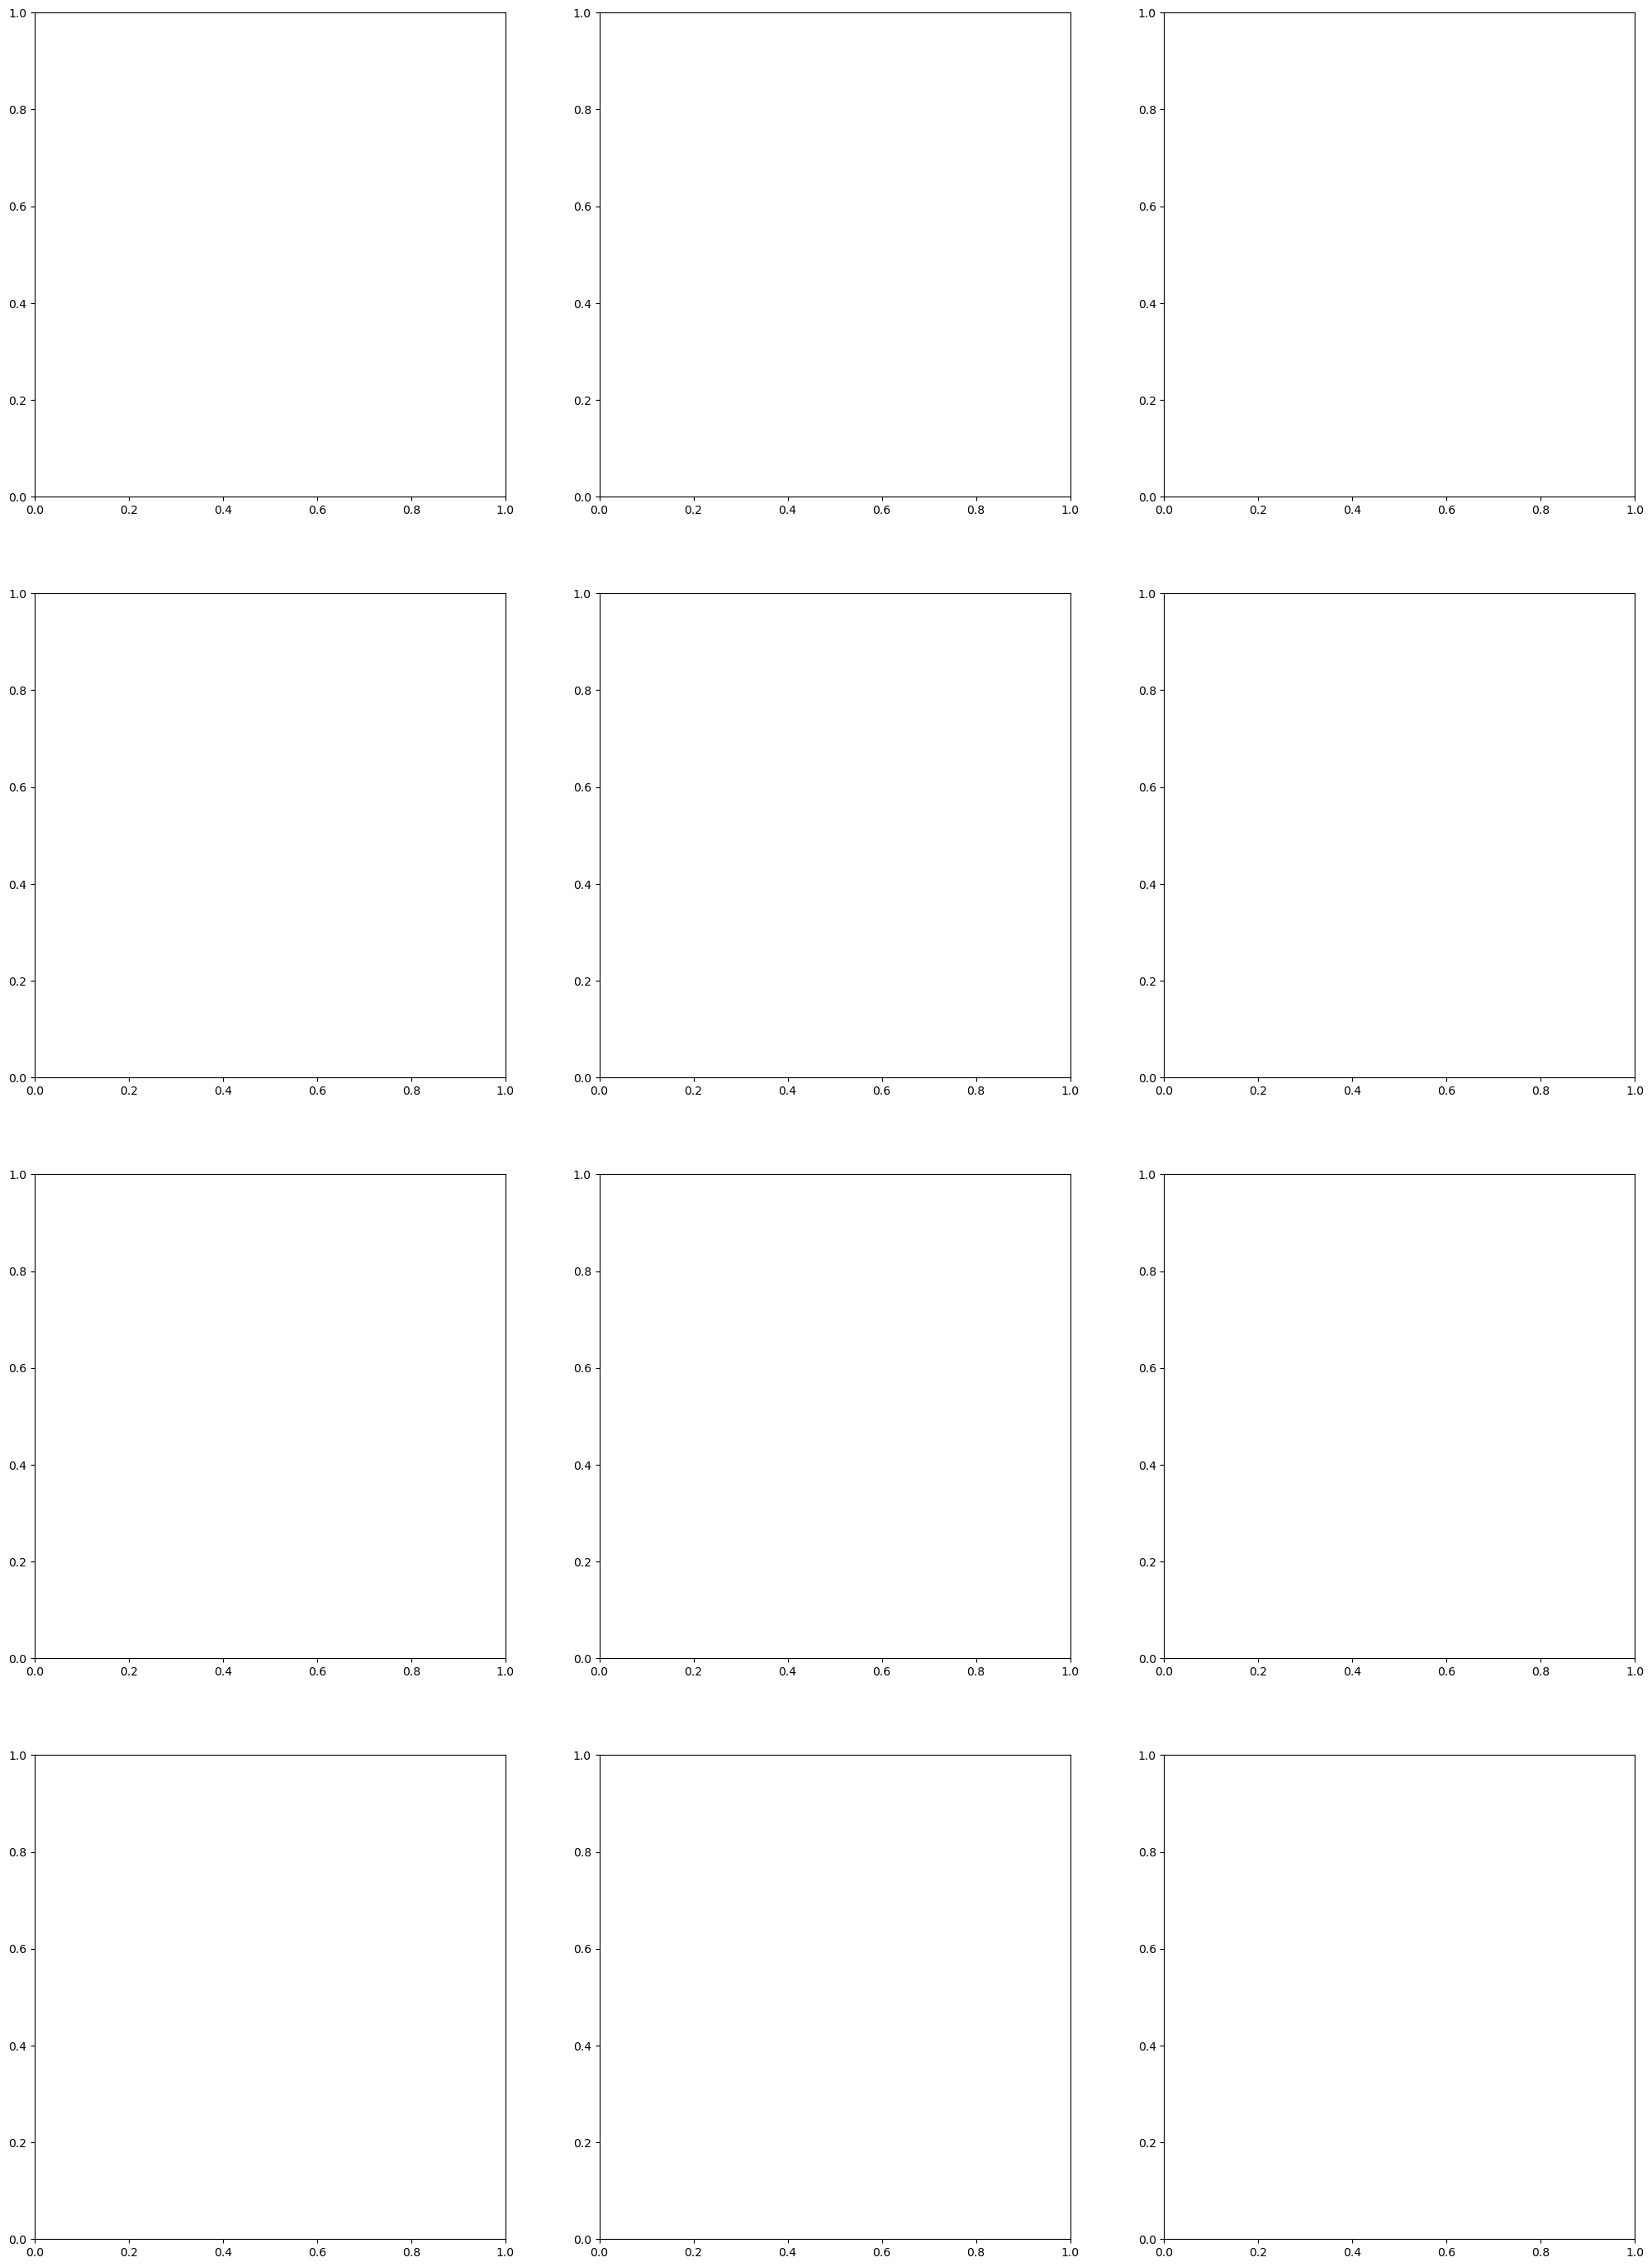

In [174]:
fig, ax = plt.subplots(4, 3, figsize=(25, 35))
ax = ax.ravel()
num = 0
i = 0
ax[num].scatter(tsne_all[label_all!=i, 0], tsne_all[label_all!=i, 1], s=2, c="gray", alpha=0.5)
ax[num].scatter(tsne_all[label_all==i, 0], tsne_all[label_all==i, 1], s=2, label="train", c='tab:orange', alpha=0.7)
ax[num].scatter(tsne_test[(test_label==i), 0], tsne_test[(test_label==i), 1], s=2, label="test", c='tab:blue')
ax[num].scatter(tsne_test[(test_label==i) & y_cut, 0], tsne_test[(test_label==i) & y_cut, 1], s=2, label="test & prob cut", c='tab:green')
ax[num].set_aspect("equal")
ax[num].set_xlabel("tSNE axis-1")
ax[num].set_ylabel("tSNE axis-2")
ax[num].set_title("good", fontsize=15)
lgnd = ax[num].legend(loc="upper right", scatterpoints=1, fontsize=10)
for hdl in lgnd.legendHandles:
    hdl._sizes = [30]
num += 1
for i, rea in enumerate(decam_info.reason_li, start=1):
    if sum(label==i) == 0:
        continue
    ax[num].scatter(tsne_all[label_all!=i, 0], tsne_all[label_all!=i, 1], s=2, c="gray", alpha=0.5)
    ax[num].scatter(tsne_all[label_all==i, 0], tsne_all[label_all==i, 1], s=2, label="train", c='tab:orange', alpha=0.7)
    ax[num].scatter(tsne_test[(test_label==i), 0], tsne_test[(test_label==i), 1], s=2, label="test", c='tab:blue')
    ax[num].scatter(tsne_test[(test_label==i) & y_cut, 0], tsne_test[(test_label==i) & y_cut, 1], s=2, label="test & prob cut", c='tab:green')
    ax[num].set_title(rea, fontsize=15)
    ax[num].set_aspect("equal")
    ax[num].set_xlabel("tSNE axis-1")
    ax[num].set_ylabel("tSNE axis-2")
    # plt.legend(loc="upper right")
    lgnd = ax[num].legend(loc="upper right", scatterpoints=1, fontsize=10)
    for hdl in lgnd.legendHandles:
        hdl._sizes = [30]
    num += 1
    # plt.show()
# ax[-1].axis("off")
# ax[-2].axis("off")
# plt.savefig(plot_dir / f"train_test_prob_subplots_pca{pca_components}_cluster{n_clusters}_percent{percent}_clustering.png", bbox_inches='tight')

In [46]:
# # now check miss classified 0 vs. 5 (7) (good vs. ghost_scatter case)
# # decam_info.reason_num_dict['Ghost_Scatter'] == 6 (+1)
# miss_class_0 = (y_test == 7) & (y_pred == 0)
# miss_class_5 = (y_test == 0) & (y_pred == 7)
# idx_miss_0 = np.array(test_idx, dtype=int)[miss_class_0]
# idx_miss_5 = np.array(test_idx, dtype=int)[miss_class_5]

import pandas as pd

dr10_dir = Path('/global/cfs/cdirs/cosmo/work/legacysurvey/dr10')
dr10_imdir = dr10_dir / "images"

df_test = pd.read_csv("/global/u1/b/brookluo/decam-exposure-quality/data/samples/test_supervised_ooi_dataset.csv")

In [47]:
pick_fp = (y_test_cut == 0) & (y_pred_cut > 0)
pick_match = (y_test_cut == y_pred_cut)
# pick_fp = pick_match

In [48]:
sum(pick_fp)

278

In [49]:
len(y_test_cut)

8100

In [50]:
import fitsio

In [51]:
# i = df_test.query("expnum == 453898").iloc[0].index

idx = np.array(test_idx, dtype=int)
label = np.array(test_label, dtype=int)

# row = df_test.iloc[idx[y_cut][pick_fp][i]]
row = df_test.query("expnum == 453898").iloc[0]
exp = row.expnum
ccdnum = row.ccdnum
ccdname = decam_info.ccdnum2name[ccdnum]
expheader = fitsio.read_header(dr10_imdir / row["image_filename"])
img, imgheader = fitsio.read(dr10_imdir / row["image_filename"], ext=row["image_hdu"], header=True)
fig, ax = plt.subplots(figsize=(6, 8))
plot_zscale_image(img, ax, 'gray')
ax.set_title(f"{exp} {ccdname}\n"
    f"Exptime: {expheader['EXPTIME']}, Filter: {expheader['FILTER'][:1]}\n"
            f"Gain: ({imgheader['GAINA']:.4f}, {imgheader['GAINB']:.4f})\n"
            f"Read Noise: ({imgheader['RDNOISEA']:.4f}, {imgheader['RDNOISEB']:.4f})")
print(imgheader['RDNOISEA'], imgheader['RDNOISEB'])
print(imgheader['GAINA'], imgheader['GAINB'])
print(expheader['EXPTIME'], expheader['FILTER'][:1])
# print(decam_info.reason_li[y_pred_cut[pick_fp][i]-1])
print(decam_info.decode_reason(row['reasons']))

IndexError: single positional indexer is out-of-bounds

In [ ]:
idx_cut_match = idx_cut[pick_match]

In [52]:
y_cut_match = y_test_cut[pick_match]

In [53]:
all_match_pick = [np.where(y_cut_match == i)[0]  for i in np.unique(y_cut_match)]

In [54]:
rng = np.random.default_rng(42)
all_match_pick_100 = [rng.choice(arr, size=100, replace=False) if len(arr) > 100 else arr for arr in all_match_pick]

In [55]:
# idx = np.array(test_idx, dtype=int)
# label = np.array(test_label, dtype=int)
# for arr in all_match_pick_100:
#     for i in arr:
#         row = df_test.iloc[idx_cut_match[i]]
#         exp = row.expnum
#         ccdnum = row.ccdnum
#         ccdname = decam_info.ccdnum2name[ccdnum]
#         all_reason = " & ".join(decam_info.decode_reason(row.reasons))
#         all_source = " & ".join(decam_info.decode_vi_source(row.vi_source))
#         if y_pred_cut[pick_fp][i] == 0:
#             reason = 'good'
#             all_reason_source = 'good'
#         else:
#             reason = decam_info.reason_li[y_cut_match[i]-1]
#             all_reason_source = f"{all_reason} by {all_source}"
#         dir_rea = Path("/global/u1/b/brookluo/decam-exposure-quality/matched_images", reason)
#         dir_rea.mkdir(exist_ok=True, parents=True)
#         # print(row.vi_source, all_source)
#         expheader = fitsio.read_header(dr10_imdir / row["image_filename"])
#         img, imgheader = fitsio.read(dr10_imdir / row["image_filename"], ext=row["image_hdu"], header=True)
#         fig, ax = plt.subplots(figsize=(6, 8))
#         plot_zscale_image(img, ax, 'gray')
#         ax.set_title(f"{exp} {ccdname}\n"
#                      f"Exptime: {expheader['EXPTIME']}, Filter: {expheader['FILTER'][:1]}\n"
#                     f"Gain: ({imgheader['GAINA']:.4f}, {imgheader['GAINB']:.4f})\n"
#                     f"Read Noise: ({imgheader['RDNOISEA']:.4f}, {imgheader['RDNOISEB']:.4f})")
#         # img = fitsio.read(dr10_imdir / row["image_filename"], ext=row["image_hdu"])
#         # fig, ax = plt.subplots(figsize=(6, 8))
#         # plot_zscale_image(img, ax, 'gray')
#         # plt.title(f"pred class: {reason}, prob: {max(y_pred_prob[y_cut][pick_fp][i])}\n"
#         #          f"{exp} {ccdname} {all_reason_source}")
#         fname = f"{exp}_{ccdname}.png"
#         plt.savefig(dir_rea / fname)
#         plt.close()


In [58]:
dir_path = Path("/global/u1/b/brookluo/decam-exposure-quality/false_negative_dr10cut")

In [56]:
idx = np.array(test_idx, dtype=int)
label = np.array(test_label, dtype=int)
idx_cut = idx[y_cut]
for i in range(len(idx_cut[pick_fp])):
    row = df_test.iloc[idx_cut[pick_fp][i]]
    exp = row.expnum
    ccdnum = row.ccdnum
    ccdname = decam_info.ccdnum2name[ccdnum]
    # all_reason = " & ".join(decam_info.decode_reason(row.reasons))
    # all_source = " & ".join(decam_info.decode_vi_source(row.vi_source))
    reason = decam_info.reason_li[y_pred_cut[pick_fp][i]-1]
    # all_reason_source = f"{all_reason} by {all_source}"
    dir_rea = Path(dir_path, reason)
    dir_rea.mkdir(exist_ok=True, parents=True)
    # print(row.vi_source, all_source)
    expheader = fitsio.read_header(dr10_imdir / row["image_filename"])
    img, imgheader = fitsio.read(dr10_imdir / row["image_filename"], ext=row["image_hdu"], header=True)
    fig, ax = plt.subplots(figsize=(6, 8))
    plot_zscale_image(img, ax, 'gray')
    ax.set_title(f"{exp} {ccdname}\n"
                 f"pred class: {reason}, prob: {max(y_pred_prob[y_cut][pick_fp][i])}\n"
                 f"Exptime: {expheader['EXPTIME']}, Filter: {expheader['FILTER'][:1]}\n"
                # f"Gain: ({imgheader['GAINA']:.4f}, {imgheader['GAINB']:.4f})\n"
                f"Read Noise: ({imgheader['RDNOISEA']:.4f}, {imgheader['RDNOISEB']:.4f})")
    fname = f"{exp}_{ccdname}.png"
    plt.savefig(dir_rea / fname)
    plt.close()


In [57]:
import os

In [157]:
html = [
    "<!DOCTYPE html>",
    "<html>",
        "<head>",
            # "<title>Expert Model matched images</title>",
            "<title>Images missed by experts</title>",
        "</head>",
        "<body>"
]

end = ["</body>", "</html>"]
# remember to include </body> </html> in the end!

dirpath = Path("/global/u1/b/brookluo/decam-exposure-quality/false_negative_dr10")

for onedir in dirpath.glob("*"):
    body = ["<table>"]
    if not onedir.is_dir():
        continue
    for i, im_name in enumerate(onedir.glob("*")):
        if i % 5 == 0:
            body.append("<tr>")
        body.append(f"<td><img src=\"{im_name.parent.name}/{im_name.name}\"></td>")
    body.append("</table>")
    with open(dirpath / f"{onedir.name}.html", "w") as fp:
        fp.write("\n".join(html + body + end))

# for i, (idx, row) in enumerate(df_test.iloc[idx[y_cut][pick_fp]].iterrows()):
#     exp = row.expnum
#     ccdnum = row.ccdnum
#     ccdname = decam_info.ccdnum2name[ccdnum]
#     fname = f"{exp}_{ccdname}.png"
#     if i % 5 == 0:
#         body.append("<tr>")
#     body.append(f"<td><img src=\"{dirpath.name}/{fname}\"></td>")
# body.append("</table>")
# with open(dirpath.parent / f"{dirpath.name}.html", "w") as fp:
#     fp.write("\n".join(html + body + end))


# This list of images are matched between human expert's label and ML model's label.
index = '''<!DOCTYPE html>
<html>
    <body>
        This is the list of images considered as "good" and used in DR10 but flagged as bad by ML model.
        <ol>
            {list}
        </ol>
    </body>
</html>
'''

all_reason = [f'<li><a href="./{r}.html">{r}</a></li>' for r in (["good"] + list(decam_info.reason_li)) if r in os.listdir(dirpath)]
with open(dirpath / "index.html", "w") as fp:
    fp.write(index.format(list="\n".join(all_reason)))

In [33]:
# import fitsio

# miss_0as5_dir = plot_dir / "misclass-good-as-ghost_scatter"
# miss_0as5_dir.mkdir(exist_ok=True)
# miss_5as0_dir = plot_dir / "misclass-ghost_scatter-as-good"
# miss_5as0_dir.mkdir(exist_ok=True)

# prob_test = knn.predict_proba(X_test)

# for i in range(len(idx_miss_0)):
#     row = df_test.loc[idx_miss_0[i]]
#     exp = row.expnum
#     ccdnum = row.ccdnum
#     ccdname = decam_info.ccdnum2name[ccdnum]
#     all_reason = " & ".join(decam_info.decode_reason(row.reasons))
#     all_source = " & ".join(decam_info.decode_vi_source(row.vi_source))
#     img = fitsio.read(dr10_imdir / row["image_filename"], ext=row["image_hdu"])
#     fig, ax = plt.subplots(figsize=(6, 8))
#     plot_zscale_image(img, ax, 'gray')
#     plt.title(f"true class: Ghost_scatter, {prob_test[miss_class_0][i, 5]}\n"
#               f"pred class: good, {prob_test[miss_class_0][i, 0]}\n"
#              f"{exp} {ccdname} {all_reason} by {all_source}")
#     fname = f"{exp}_{ccdname}.png"
#     plt.savefig(miss_5as0_dir / fname)
#     plt.close()

# for i in range(len(idx_miss_5)):
#     row = df_test.loc[idx_miss_5[i]]
#     exp = row.expnum
#     ccdnum = row.ccdnum
#     ccdname = decam_info.ccdnum2name[ccdnum]
#     all_reason = " & ".join(decam_info.decode_reason(row.reasons))
#     all_source = " & ".join(decam_info.decode_vi_source(row.vi_source))
#     img = fitsio.read(dr10_imdir / row["image_filename"], ext=row["image_hdu"])
#     fig, ax = plt.subplots(figsize=(6, 8))
#     plot_zscale_image(img, ax, 'gray')
#     plt.title(
#         f"true class: good, {prob_test[miss_class_5][i, 0]}\n"
#         f"pred class: Ghost_scatter, {prob_test[miss_class_5][i, 5]}\n"
#         f"{exp} {ccdname}")
#     fname = f"{exp}_{ccdname}.png"
#     plt.savefig(miss_0as5_dir / fname)
#     plt.close()

# html = [
#     "<!DOCTYPE html>",
#     "<html>",
#         "<head>",
#             "<title>Misclassify {truth} as {pred}</title>",
#         "</head>",
#         "<body>"
# ]

# end = ["</body>", "</html>"]
# # remember to include </body> </html> in the end!

# def write_website(df, dirpath, truth, pred):
#     body = ["<table>"]
#     for i, (idx, row) in enumerate(df.iterrows()):
#         exp = row.expnum
#         ccdnum = row.ccdnum
#         ccdname = decam_info.ccdnum2name[ccdnum]
#         fname = f"{exp}_{ccdname}.png"
#         if i % 5 == 0:
#             body.append("<tr>")
#         body.append(f"<td><img src=\"{dirpath.name}/{fname}\"></td>")
#     body.append("</table>")
#     with open(plot_dir / f"{dirpath.name}.html", "w") as fp:
#         fp.write("\n".join(html + body + end).format(truth=truth, pred=pred))

# write_website(df_test.loc[idx_miss_5].sort_values("expnum"), miss_0as5_dir, "good", "ghost_scatter")
# write_website(df_test.loc[idx_miss_0].sort_values("expnum"), miss_5as0_dir, "ghost_scatter", "good")

# index = '''<!DOCTYPE html>
# <html>
#     <body>
#         This is the list of misclassified images.
#         <ol>
#             {list}
#         </ol>
#     </body>
# </html>
# '''

# all_reason = [f'<li><a href="./{r}.html">{r}</a></li>' for r in reason_expnum_fp.keys()]
# with open(f"../images/index.html", "w") as fp:
#     fp.write(index.format(list="\n".join(all_reason)))